# Netflix Catalog: Exploratory Data Analysis

**Gokul Prasanth · Python, Pandas, NumPy, Matplotlib & Seaborn**

## tl;dr

This historical dataset contains **8,807 titles: 6,131 movies (69.6%) and
2,676 TV shows (30.4%)**. Recorded additions peak in **2019 with 2,016 titles**.
The United States is associated with **3,690 unique titles**; International
Movies is the largest listed category with **2,752 titles**.

The latest recorded addition is **September 25, 2021**. These results describe
the supplied snapshot, not Netflix's current catalog, audience demand, or revenue.
The 2021 period is incomplete and ten titles have no addition date.

## Context & Methods

**Question:** How does the supplied catalog vary by content type, addition year,
country, genre, rating, contributor, and duration?

This notebook retains the original project's cleaning, relationship-table,
univariate, bivariate, and cross-dimensional analyses. The workflow is a
descriptive portfolio study; commercial implications are questions for further
investigation rather than investment recommendations.

### Key Assumptions

- One `show_id` represents one title. Country, genre, director, and cast tables
  contain distinct title–attribute relationships. Multi-country and multi-genre
  counts overlap and must not be added to obtain unique title counts.
- `date_added` is a recorded catalog addition date, not the release date or a
  measure of net catalog growth. Removal history is unavailable.
- Blank/unknown metadata is excluded from named-entity rankings; titles remain
  in the main table. Missing dates remain missing.
- Three runtimes misplaced in `rating` are transferred to missing `duration`
  fields in the analysis copy; the corresponding ratings become `Unknown`.
- Negative values of addition year minus release year are retained for audit
  and excluded from age summaries. This is a year-based proxy, not exact elapsed time.
- No viewership, costs, subscriber, revenue, or country-level availability data
  is supplied, so catalog presence cannot establish popularity or profitability.

**Source:** the repository's `data/netflix.csv`, preserved byte-for-byte from
original commit `5e4a68f`. The original repository did not document its upstream
publisher or redistribution license; neither is assumed here.

**Run:** install `requirements.txt` from the repository root, then open this
notebook. Run all cells in order. The six README figures are regenerated in `images/`.

## Data

### 1. Load and audit the source

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, StrMethodFormatter
import seaborn as sns
from IPython.display import display

# Support execution from either the repository root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'netflix.csv'
IMAGE_DIR = PROJECT_ROOT / 'images'
IMAGE_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
assert df['show_id'].notna().all() and df['show_id'].is_unique
assert set(df['type']) == {'Movie', 'TV Show'}
df.sample(5, random_state=26)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3597,s3598,TV Show,Knightfall,NaN,"Tom Cullen, Jim Carter, Pádraic Delaney, Simon...",United States,"August 13, 2019",2019,TV-MA,2 Seasons,TV Dramas,Fifteen years after the Crusades ended in defe...
8781,s8782,Movie,Yo-Kai Watch: The Movie,Mark Risley,"Johnny Yong Bosch, Joey D'Auria, Alicyn Packar...","Japan, United States","December 1, 2016",2016,TV-Y7,96 min,"Anime Features, Children & Family Movies",Nate's special Yo-Kai Watch is missing. He tra...
4491,s4492,Movie,Derren Brown: Sacrifice,NaN,Derren Brown,NaN,"October 19, 2018",2018,TV-MA,50 min,Movies,Illusionist Derren Brown concocts a psychologi...
868,s869,TV Show,The Magic School Bus,NaN,"Lily Tomlin, Daniel DeSanto, Erica Luttrell, M...","Canada, United States","May 19, 2021",1997,TV-Y,1 Season,Kids' TV,Join Ms. Frizzle as the Magic School Bus trave...
8673,s8674,Movie,Vegas Baby,Amanda Micheli,NaN,United States,"July 4, 2017",2016,TV-14,78 min,Documentaries,A Las Vegas doctor's controversial online cont...


In [2]:
pd.Series({'Titles': len(df), 'Source columns': df.shape[1], 'Duplicate title IDs': df['show_id'].duplicated().sum()})

Titles                 8807
Source columns           12
Duplicate title IDs       0
dtype: int64

In [3]:
missing_values = pd.DataFrame({
    'Missing rows': df.isna().sum(),
    'Missing (%)': df.isna().mean().mul(100).round(1),
})
missing_values.loc[missing_values['Missing rows'] > 0].sort_values('Missing rows', ascending=False)

,Missing rows,Missing (%)
director,2634,29.9
country,831,9.4
cast,825,9.4
date_added,10,0.1
rating,4,0.0
duration,3,0.0


### 2. Clean descriptive fields

Keep the raw dataframe and CSV unchanged. `Unknown` flags missing metadata;
it is not an inferred director, actor, country, genre, or rating.

In [4]:
df_clean = df.copy(deep=True)
for column in ['director', 'cast', 'country', 'listed_in', 'rating']:
    df_clean[column] = df_clean[column].fillna('Unknown').str.strip()
df_clean[['show_id', 'title', 'director', 'cast']].head(5)

,show_id,title,director,cast
0,s1,Dick Johnson Is Dead,Kirsten Johnson,Unknown
1,s2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban..."
2,s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi..."
3,s4,Jailbirds New Orleans,Unknown,Unknown
4,s5,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K..."


### 3. Build title–director and title–cast relationships

Split comma-separated metadata, trim each token, and remove blank/unknown
tokens and duplicate title–attribute pairs. Each table is one-to-many relative
to the title table; it is not a one-to-one mapping.

In [5]:
df_clean['director_list'] = df_clean['director'].str.split(',')
df_clean['cast_list'] = df_clean['cast'].str.split(',')
for column in ['director_list', 'cast_list']:
    df_clean[column] = df_clean[column].apply(lambda values: [value.strip() for value in values])
df_clean[['title', 'director_list', 'cast_list']].head(5)

,title,director_list,cast_list
0,Dick Johnson Is Dead,[Kirsten Johnson],[Unknown]
1,Blood & Water,[Unknown],"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba..."
2,Ganglands,[Julien Leclercq],"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nab..."
3,Jailbirds New Orleans,[Unknown],[Unknown]
4,Kota Factory,[Unknown],"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam ..."


In [6]:
title_cast = (
    df_clean[['show_id', 'title', 'cast_list']]
    .explode('cast_list').rename(columns={'cast_list': 'cast_member'})
)
title_cast.head(5)

,show_id,title,cast_member
0,s1,Dick Johnson Is Dead,Unknown
1,s2,Blood & Water,Ama Qamata
1,s2,Blood & Water,Khosi Ngema
1,s2,Blood & Water,Gail Mabalane
1,s2,Blood & Water,Thabang Molaba


In [7]:
title_director = (
    df_clean[['show_id', 'title', 'director_list']]
    .explode('director_list').rename(columns={'director_list': 'director'})
)
title_director.head(5)

,show_id,title,director
0,s1,Dick Johnson Is Dead,Kirsten Johnson
1,s2,Blood & Water,Unknown
2,s3,Ganglands,Julien Leclercq
3,s4,Jailbirds New Orleans,Unknown
4,s5,Kota Factory,Unknown


In [8]:
title_director = title_director.loc[~title_director['director'].isin(['Unknown', ''])].copy()
title_cast = title_cast.loc[~title_cast['cast_member'].isin(['Unknown', ''])].copy()

In [9]:
pd.Series({
    'Repeated title–cast pairs': title_cast.duplicated(['show_id', 'cast_member']).sum(),
    'Repeated title–director pairs': title_director.duplicated(['show_id', 'director']).sum(),
})

Repeated title–cast pairs        2
Repeated title–director pairs    1
dtype: int64

In [10]:
title_cast = title_cast.drop_duplicates(['show_id', 'cast_member'])
title_director = title_director.drop_duplicates(['show_id', 'director'])

### 4. Clean countries, genres, dates, ratings, and duration

In [11]:
df_clean['country_list'] = df_clean['country'].str.split(',').apply(
    lambda values: [value.strip() for value in values]
)
title_country = (
    df_clean[['show_id', 'title', 'country_list']]
    .explode('country_list').rename(columns={'country_list': 'country'})
)
title_country = title_country.loc[~title_country['country'].isin(['Unknown', ''])]
title_country = title_country.drop_duplicates(['show_id', 'country'])
title_country.head(5)

,show_id,title,country
0,s1,Dick Johnson Is Dead,United States
1,s2,Blood & Water,South Africa
4,s5,Kota Factory,India
7,s8,Sankofa,United States
7,s8,Sankofa,Ghana


In [12]:
df_clean['genre_list'] = df_clean['listed_in'].str.split(',').apply(
    lambda values: [value.strip() for value in values]
)
title_genre = (
    df_clean[['show_id', 'title', 'genre_list']]
    .explode('genre_list').rename(columns={'genre_list': 'genre'})
)
title_genre = title_genre.loc[~title_genre['genre'].isin(['Unknown', ''])]
title_genre = title_genre.drop_duplicates(['show_id', 'genre'])
title_genre.head(5)

,show_id,title,genre
0,s1,Dick Johnson Is Dead,Documentaries
1,s2,Blood & Water,International TV Shows
1,s2,Blood & Water,TV Dramas
1,s2,Blood & Water,TV Mysteries
2,s3,Ganglands,Crime TV Shows


In [13]:
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'].str.strip(), format='%B %d, %Y', errors='coerce'
)
assert df_clean['date_added'].isna().sum() == df['date_added'].isna().sum()
pd.Series({
    'Earliest recorded addition': df_clean['date_added'].min(),
    'Latest recorded addition': df_clean['date_added'].max(),
    'Missing addition dates': df_clean['date_added'].isna().sum(),
})

Earliest recorded addition    2008-01-01 00:00:00
Latest recorded addition      2021-09-25 00:00:00
Missing addition dates                         10
dtype: object

In [14]:
df_clean['added_year'] = df_clean['date_added'].dt.year.astype('Int64')
df_clean['added_month'] = df_clean['date_added'].dt.month.astype('Int64')
df_clean['added_month_name'] = df_clean['date_added'].dt.month_name()

In [15]:
misplaced_runtime = df_clean['rating'].str.fullmatch(r'\d+ min', na=False)
runtime_repair = misplaced_runtime & df_clean['duration'].isna() & df_clean['type'].eq('Movie')
display(df_clean.loc[runtime_repair, ['show_id', 'title', 'rating', 'duration']])
df_clean.loc[runtime_repair, 'duration'] = df_clean.loc[runtime_repair, 'rating']
df_clean.loc[misplaced_runtime, 'rating'] = 'Unknown'

duration_value = pd.to_numeric(df_clean['duration'].str.extract(r'(\d+)')[0], errors='coerce')
df_clean['movie_duration_min'] = duration_value.where(df_clean['type'].eq('Movie'))
df_clean['tv_seasons'] = duration_value.where(df_clean['type'].eq('TV Show'))
df_clean[['title', 'rating', 'movie_duration_min', 'tv_seasons']].head(5)

,show_id,title,rating,duration
5541,s5542,Louis C.K. 2017,74 min,NaN
5794,s5795,Louis C.K.: Hilarious,84 min,NaN
5813,s5814,Louis C.K.: Live at the Comedy Store,66 min,NaN


,title,rating,movie_duration_min,tv_seasons
0,Dick Johnson Is Dead,PG-13,90.0,NaN
1,Blood & Water,TV-MA,NaN,2.0
2,Ganglands,TV-MA,NaN,1.0
3,Jailbirds New Orleans,TV-MA,NaN,1.0
4,Kota Factory,TV-MA,NaN,2.0


In [16]:
# Null runtimes on TV shows and null season counts on movies are intentional.
df_clean[['date_added', 'movie_duration_min', 'tv_seasons']].isna().sum()

date_added              10
movie_duration_min    2676
tv_seasons            6131
dtype: int64

## Results

### 5. Content mix and recorded additions

All title counts refer to this historical snapshot. Annual counts include only
records with known addition dates, and 2021 is incomplete. Additions among
surviving snapshot records do not measure historical catalog size or net growth.

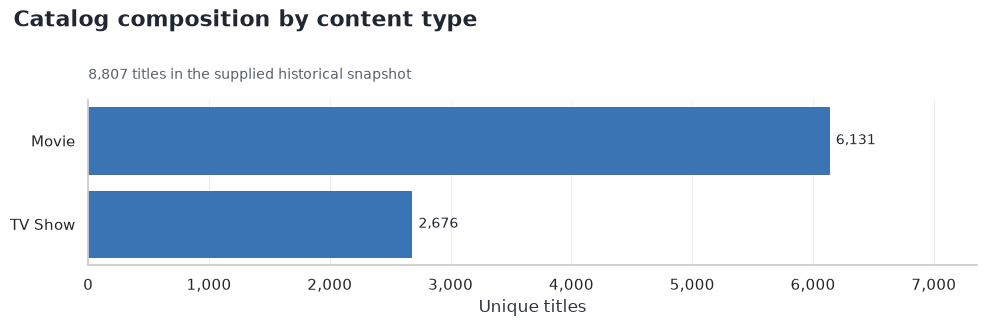

In [17]:
# Consistent plotting style and reproducible PNG exports for the README.
BLUE, GOLD, ORANGE, OLIVE, PINK = '#3B74B5', '#B68A28', '#CF7834', '#7A8640', '#B96891'
PALETTE = [BLUE, GOLD, ORANGE, OLIVE, PINK]
sns.set_theme(style='whitegrid', context='notebook', palette=PALETTE)
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelcolor': '#303641', 'text.color': '#202733',
    'grid.color': '#E7E9ED', 'grid.linewidth': 0.6,
    'axes.prop_cycle': plt.cycler(color=PALETTE),
    'figure.dpi': 100, 'savefig.dpi': 160,
})

def finish_plot(ax, title, subtitle, filename=None):
    fig = ax.figure
    fig.suptitle(title, x=0.02, ha='left', fontsize=16, fontweight='bold', y=1.01)
    ax.set_title(subtitle, loc='left', fontsize=10, color='#56616D', pad=15)
    fig.tight_layout()
    if filename:
        fig.savefig(IMAGE_DIR / filename, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)

def rank_plot(values, title, subtitle, filename=None, xlabel='Unique titles'):
    values = values.sort_values()
    fig, ax = plt.subplots(figsize=(10, max(3.2, len(values) * 0.40 + 1.3)))
    bars = ax.barh(values.index, values.values, color=BLUE, edgecolor='#24517F', linewidth=0.5)
    ax.bar_label(bars, labels=[f'{value:,.0f}' for value in values.values], padding=5, fontsize=10)
    ax.set_xlim(0, values.max() * 1.20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.grid(axis='y', visible=False)
    finish_plot(ax, title, subtitle, filename)

def grouped_plot(table, title, subtitle, percent=False):
    ax = table.plot.barh(figsize=(11, max(4, len(table) * 0.55)), color=PALETTE, edgecolor='white')
    ax.set_xlabel('Share of titles (%)' if percent else 'Unique titles')
    ax.set_ylabel('')
    ax.set_xlim(left=0)
    ax.legend(title=None, loc='best')
    finish_plot(ax, title, subtitle)

def trend_plot(table, title, subtitle, ylabel='Titles', partial=True):
    ax = table.sort_index().plot(figsize=(11, 4.5), marker='o', markersize=4, color=PALETTE)
    ax.set_xlabel('Year of recorded addition')
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if partial and 2021 in table.index:
        ax.axvspan(2020.5, 2021.5, color='#EDF0F4', zorder=0)
    finish_plot(ax, title, subtitle)

type_counts = df_clean['type'].value_counts()
rank_plot(type_counts, 'Catalog composition by content type',
          '8,807 titles in the supplied historical snapshot', 'content_type_distribution.png')

In [18]:
content_summary = pd.DataFrame({
    'Titles': type_counts,
    'Share (%)': type_counts.div(len(df_clean)).mul(100).round(1),
})
content_summary

,Titles,Share (%)
type,,
Movie,6131,69.6
TV Show,2676,30.4


#### Title added to Netflix for each year

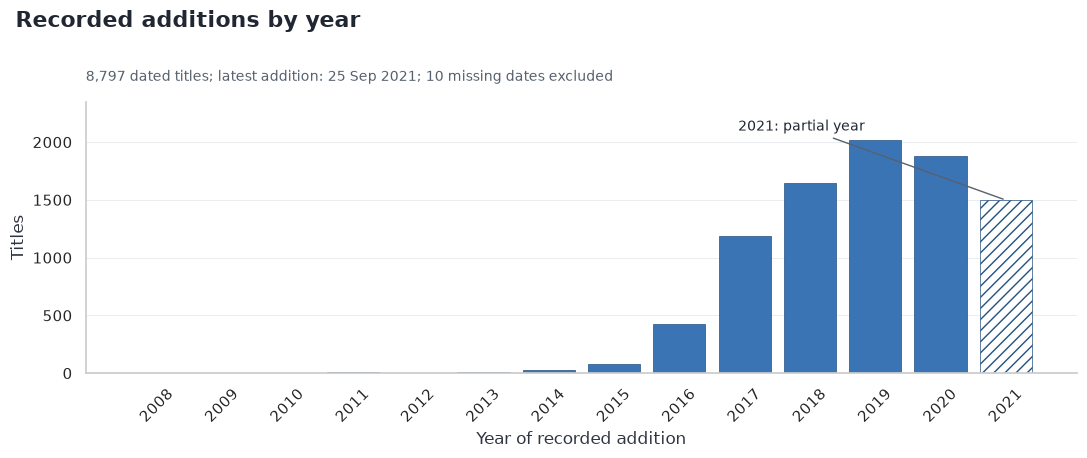

In [19]:
added_year_count = df_clean['added_year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(added_year_count.index.astype(int), added_year_count.values,
              color=BLUE, edgecolor='#24517F', linewidth=0.5)
bars[-1].set_facecolor('white')
bars[-1].set_hatch('///')
ax.annotate('2021: partial year', (2021, added_year_count.loc[2021]),
            xytext=(2016.9, 2100), arrowprops={'arrowstyle': '-', 'color': '#56616D'}, fontsize=10)
ax.set_xticks(added_year_count.index.astype(int))
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel('Year of recorded addition')
ax.set_ylabel('Titles')
ax.set_ylim(0, 2350)
ax.grid(axis='x', visible=False)
finish_plot(ax, 'Recorded additions by year',
            '8,797 dated titles; latest addition: 25 Sep 2021; 10 missing dates excluded',
            'recorded_additions_by_year.png')

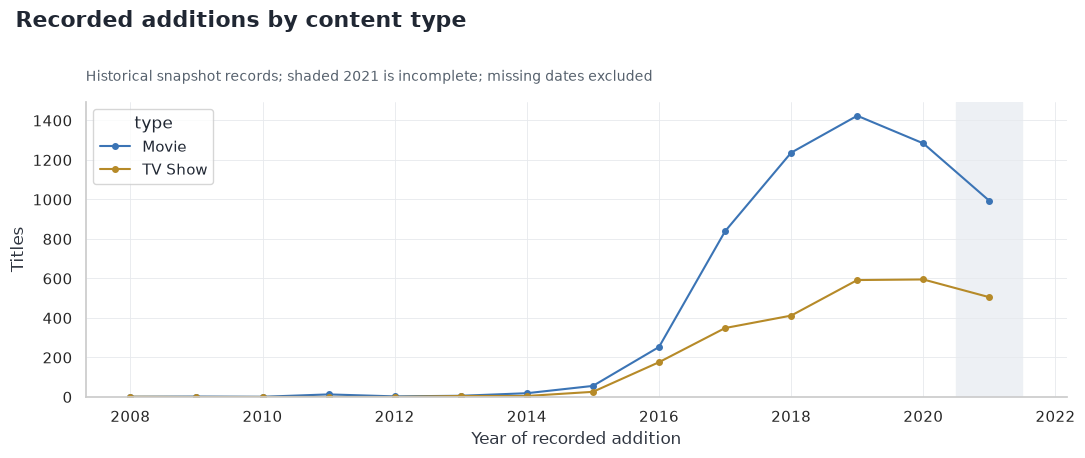

In [20]:
content_growth = pd.crosstab(df_clean['added_year'], df_clean['type'])
trend_plot(content_growth, 'Recorded additions by content type',
           'Historical snapshot records; shaded 2021 is incomplete; missing dates excluded')

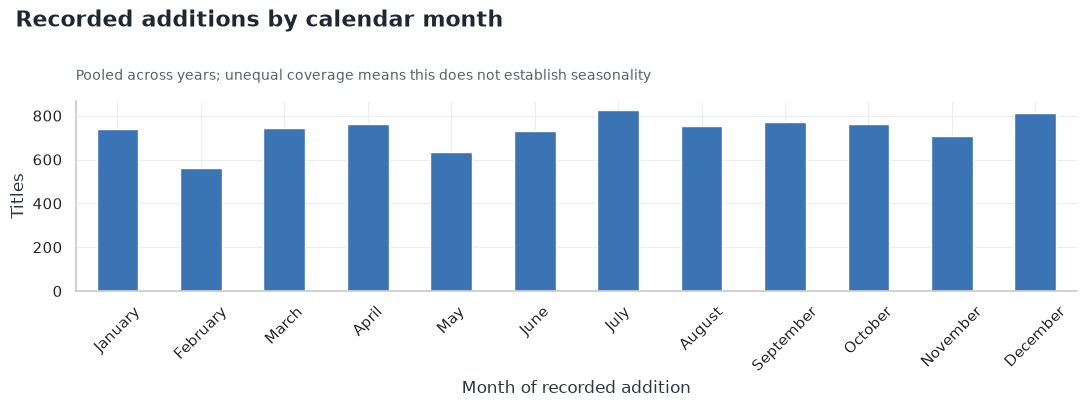

In [21]:
month_names = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_counts = df_clean['added_month_name'].value_counts().reindex(month_names, fill_value=0)
ax = monthly_counts.plot.bar(figsize=(11, 4), color=BLUE)
ax.set_ylabel('Titles')
ax.set_xlabel('Month of recorded addition')
ax.tick_params(axis='x', rotation=45)
finish_plot(ax, 'Recorded additions by calendar month',
            'Pooled across years; unequal coverage means this does not establish seasonality')

### 6. Geographic analysis

Countries are metadata associations, not audience locations. A co-production counts once in each associated country; unknown and blank tokens are excluded.

#### Which countries contribute the most Netflix titles?

In [22]:
country_count = title_country.groupby('country')['show_id'].nunique().sort_values(ascending=False)
country_count.head(10)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: show_id, dtype: int64

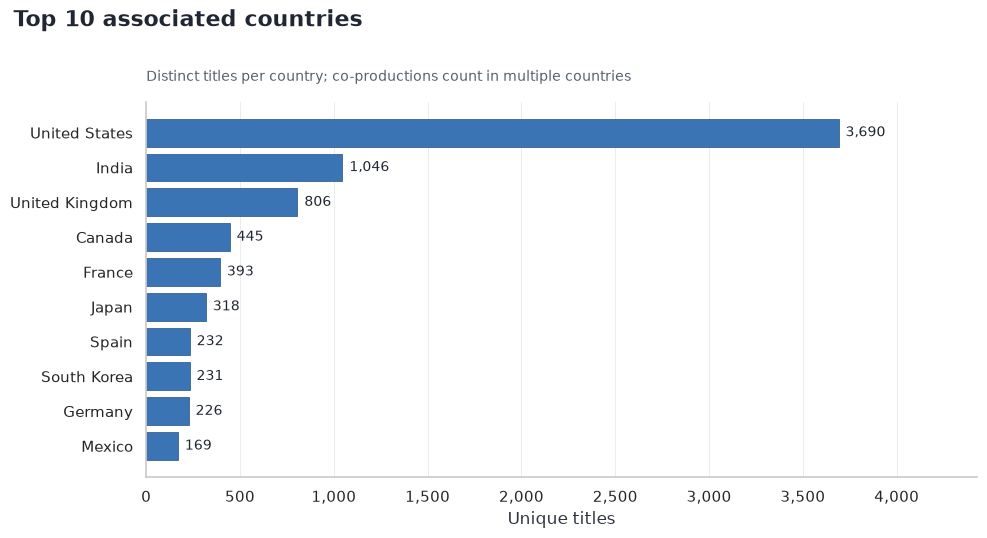

In [23]:
rank_plot(country_count.head(10), 'Top 10 associated countries',
          'Distinct titles per country; co-productions count in multiple countries', 'top_10_countries.png')

#### Movies vs TV Shows by Country

In [24]:
# Keep the complete join; head() is only for previewing the result.
country_type = title_country.merge(df_clean[['show_id', 'type']], on='show_id', how='left', validate='many_to_one')
country_type.head(5)

,show_id,title,country,type
0,s1,Dick Johnson Is Dead,United States,Movie
1,s2,Blood & Water,South Africa,TV Show
2,s5,Kota Factory,India,TV Show
3,s8,Sankofa,United States,Movie
4,s8,Sankofa,Ghana,Movie


In [25]:
country_type_table = pd.crosstab(country_type['country'], country_type['type'])
country_type_table.head(5)

type,Movie,TV Show
country,,
Afghanistan,1,0
Albania,1,0
Algeria,3,0
Angola,1,0
Argentina,71,20


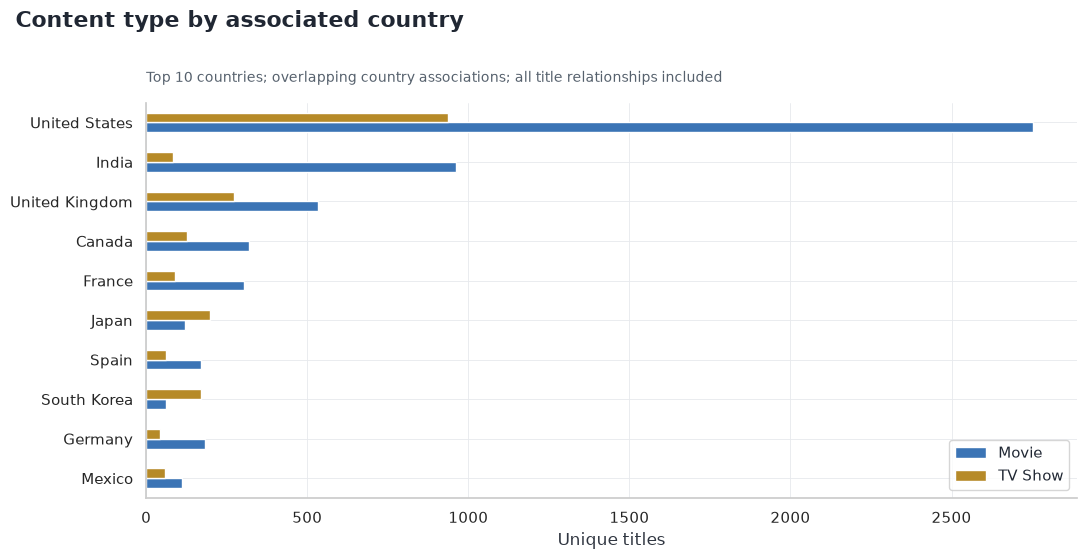

In [26]:
top10 = country_count.head(10).index
grouped_plot(country_type_table.loc[top10].iloc[::-1], 'Content type by associated country',
             'Top 10 countries; overlapping country associations; all title relationships included')

#### Share of titles associated with each country

In [27]:
country_percentage = country_count.div(len(df_clean)).mul(100).round(2)
country_percentage.head(10).rename('Share of all 8,807 titles (%)')
# Shares overlap because a title can be associated with more than one country.

country
United States     41.90
India             11.88
United Kingdom     9.15
Canada             5.05
France             4.46
Japan              3.61
Spain              2.63
South Korea        2.62
Germany            2.57
Mexico             1.92
Name: Share of all 8,807 titles (%), dtype: float64

#### Countries represented in both content types

In [28]:
represented_types = country_type.groupby('country')['type'].nunique()
both_types = represented_types.loc[represented_types.eq(2)]
print(f'{len(both_types)} countries have both movies and TV shows in this snapshot.')
both_types.head(10)

60 countries have both movies and TV shows in this snapshot.


country
Argentina    2
Australia    2
Austria      2
Belgium      2
Brazil       2
Canada       2
Chile        2
China        2
Colombia     2
Croatia      2
Name: type, dtype: int64

#### How many titles were added each year from each country?

In [29]:
country_year_data = title_country.merge(df_clean[['show_id', 'added_year']], on='show_id', validate='many_to_one')
country_year = pd.crosstab(country_year_data['added_year'], country_year_data['country'])

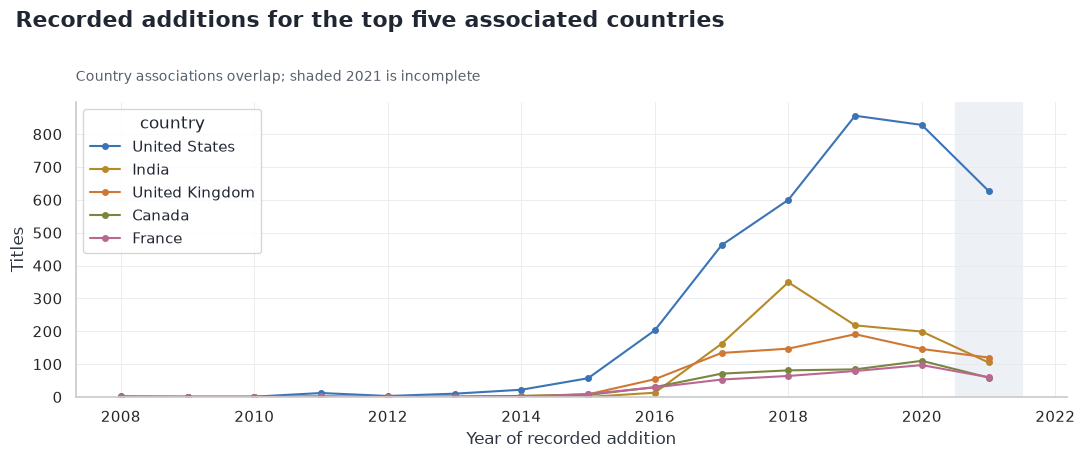

In [30]:
top5 = country_count.head(5).index
trend_plot(country_year[top5], 'Recorded additions for the top five associated countries',
           'Country associations overlap; shaded 2021 is incomplete')

In [31]:
country_release = title_country.merge(df_clean[['show_id','release_year']],on='show_id')
country_release.head()

,show_id,title,country,release_year
0,s1,Dick Johnson Is Dead,United States,2020
1,s2,Blood & Water,South Africa,2021
2,s5,Kota Factory,India,2021
3,s8,Sankofa,United States,1993
4,s8,Sankofa,Ghana,1993


In [32]:
country_release.groupby('country')['release_year'].agg(['count', 'mean']).round(1).loc[country_count.head(10).index]

,count,mean
country,,
United States,3690,2013.1
India,1046,2012.0
United Kingdom,806,2013.8
Canada,445,2015.0
France,393,2013.8
Japan,318,2013.9
Spain,232,2016.9
South Korea,231,2017.1
Germany,226,2013.6


#### Countries associated with additions recorded in 2021 (partial year)

In [33]:
country_year_data.loc[country_year_data['added_year'].eq(2021)].groupby('country')['show_id'].nunique().sort_values(ascending=False).head(10)

country
United States     627
United Kingdom    120
India             105
France             60
Canada             59
Japan              53
Germany            40
Spain              33
South Korea        29
Nigeria            28
Name: show_id, dtype: int64

### 7. Genre and listed-category analysis

`listed_in` includes broad catalog labels such as International Movies as well as genres. A title can have several labels.

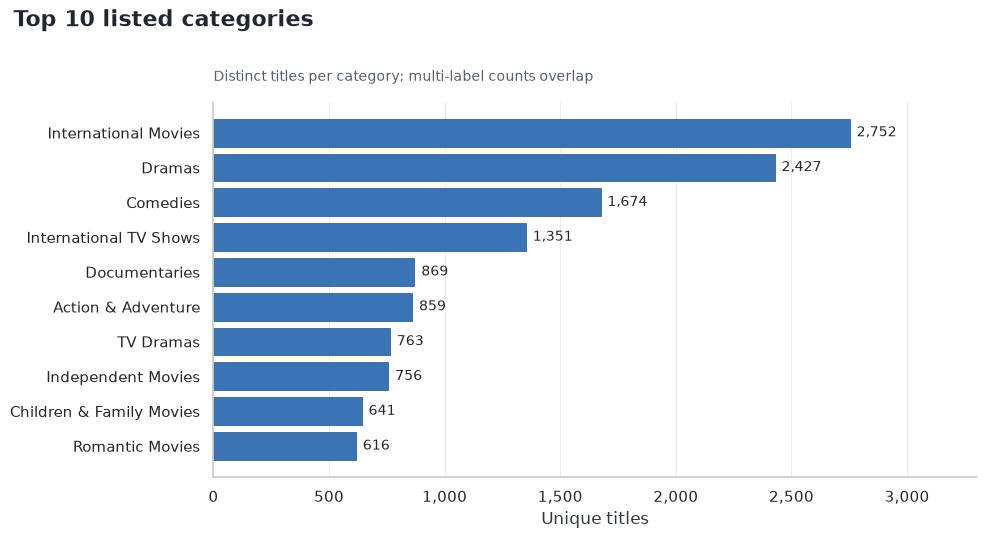

In [34]:
genre_count = title_genre.groupby('genre')['show_id'].nunique().sort_values(ascending=False)
rank_plot(genre_count.head(10), 'Top 10 listed categories',
          'Distinct titles per category; multi-label counts overlap', 'top_10_genres.png')

#### Difference in Genre with Movies VS TV Show

In [35]:
genre_type = title_genre.merge(df_clean[['show_id', 'type']], on='show_id', how='left', validate='many_to_one')
genre_type.head(5)

,show_id,title,genre,type
0,s1,Dick Johnson Is Dead,Documentaries,Movie
1,s2,Blood & Water,International TV Shows,TV Show
2,s2,Blood & Water,TV Dramas,TV Show
3,s2,Blood & Water,TV Mysteries,TV Show
4,s3,Ganglands,Crime TV Shows,TV Show


In [36]:
genre_type_table = pd.crosstab(genre_type['genre'],genre_type['type'])
genre_type_table.head()

type,Movie,TV Show
genre,,
Action & Adventure,859,0
Anime Features,71,0
Anime Series,0,176
British TV Shows,0,253
Children & Family Movies,641,0


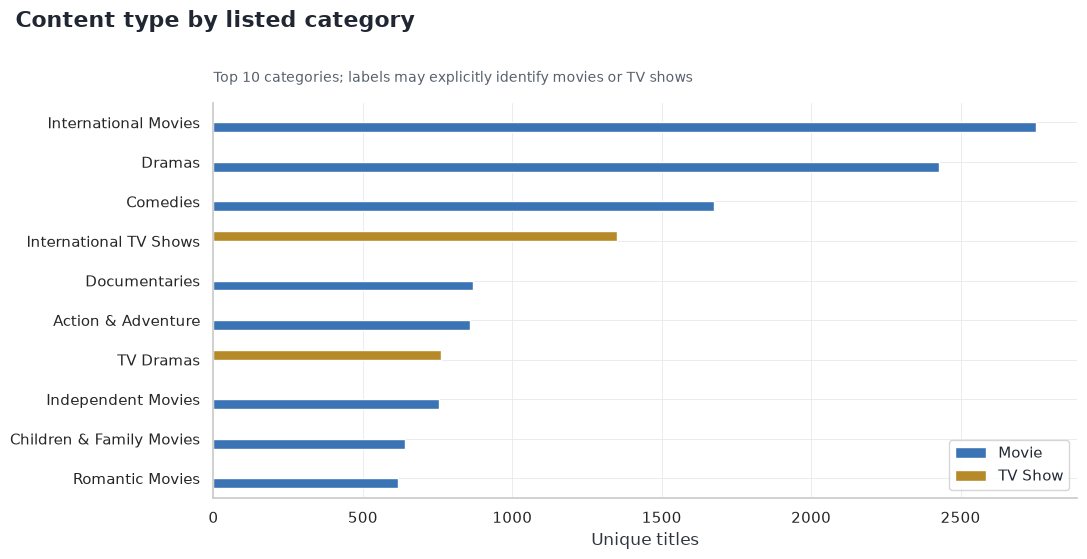

In [37]:
top_genres = genre_count.head(10).index
grouped_plot(genre_type_table.loc[top_genres].iloc[::-1], 'Content type by listed category',
             'Top 10 categories; labels may explicitly identify movies or TV shows')

#### Which genres are particularly strong for Movies?

In [38]:
movie_genres = genre_type.loc[genre_type['type'].eq('Movie'), 'genre'].value_counts()
tv_genres = genre_type.loc[genre_type['type'].eq('TV Show'), 'genre'].value_counts()

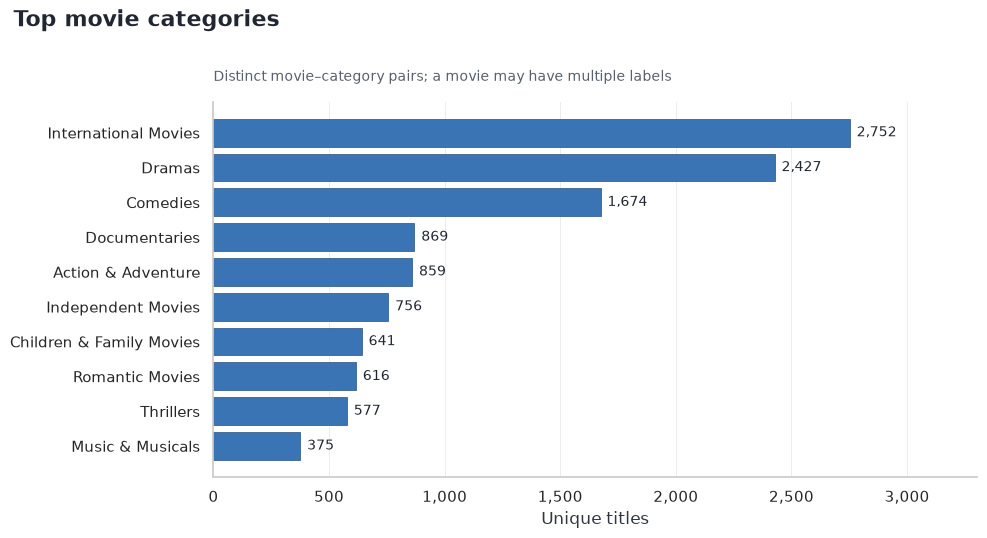

In [39]:
rank_plot(movie_genres.head(10), 'Top movie categories', 'Distinct movie–category pairs; a movie may have multiple labels')

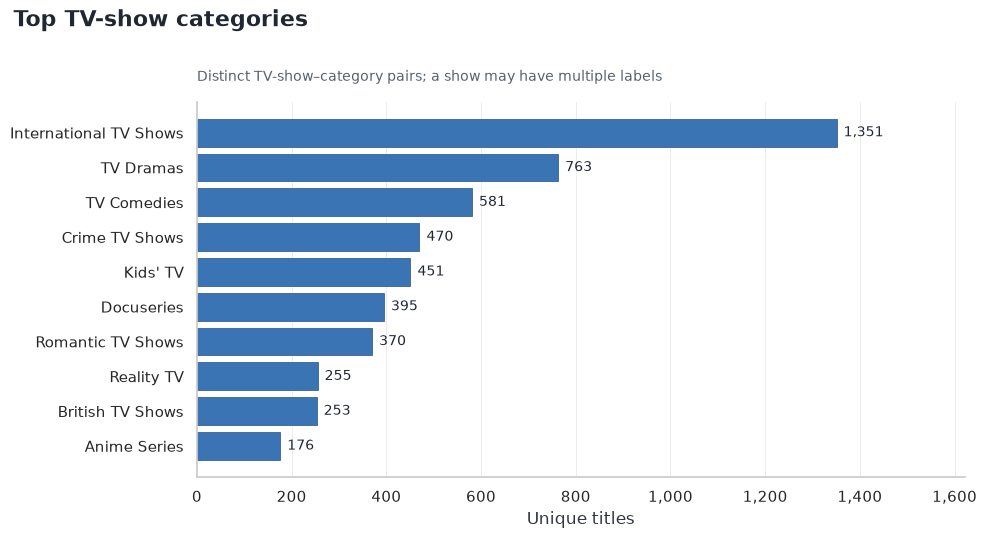

In [40]:
rank_plot(tv_genres.head(10), 'Top TV-show categories', 'Distinct TV-show–category pairs; a show may have multiple labels')

#### What percentage of Movies belong to each genre?

In [41]:
# Divide by movies, not all movie–genre relationships. A pie would falsely imply exclusivity.
movie_genre_percentage = movie_genres.div(type_counts['Movie']).mul(100).round(2)
tv_genre_percentage = tv_genres.div(type_counts['TV Show']).mul(100).round(2)
pd.DataFrame({'Movie titles': movie_genres.head(10), 'Share of 6,131 movies (%)': movie_genre_percentage.head(10)})

,Movie titles,"Share of 6,131 movies (%)"
genre,,
International Movies,2752,44.89
Dramas,2427,39.59
Comedies,1674,27.30
Documentaries,869,14.17
Action & Adventure,859,14.01
Independent Movies,756,12.33
Children & Family Movies,641,10.46
Romantic Movies,616,10.05
Thrillers,577,9.41


In [42]:
tv_genre_percentage.head(10).rename('Share of 2,676 TV shows (%)')

genre
International TV Shows    50.49
TV Dramas                 28.51
TV Comedies               21.71
Crime TV Shows            17.56
Kids' TV                  16.85
Docuseries                14.76
Romantic TV Shows         13.83
Reality TV                 9.53
British TV Shows           9.45
Anime Series               6.58
Name: Share of 2,676 TV shows (%), dtype: float64

#### How many different genres exist for each type

In [43]:
genre_type.groupby('type')['genre'].nunique().rename('Distinct listed categories')

type
Movie      20
TV Show    22
Name: Distinct listed categories, dtype: int64

#### Genre growth over time

In [44]:
genre_year = title_genre.merge(df_clean[['show_id', 'added_year', 'added_month']], on='show_id', how='left', validate='many_to_one')

In [45]:
top5_genres = genre_count.head(5).index
genre_year_top5 = genre_year.loc[genre_year['genre'].isin(top5_genres)]
genre_trend = pd.crosstab(genre_year_top5['added_year'], genre_year_top5['genre'])

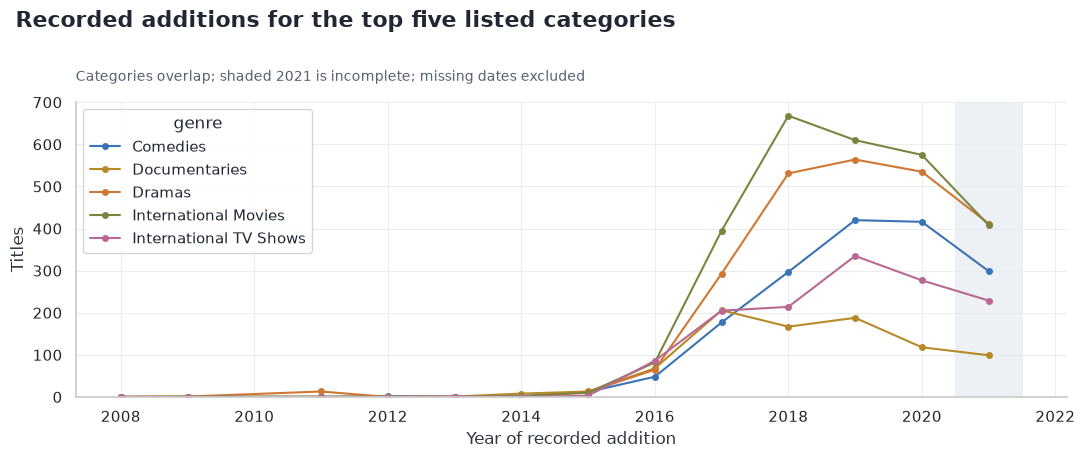

In [46]:
trend_plot(genre_trend, 'Recorded additions for the top five listed categories', 'Categories overlap; shaded 2021 is incomplete; missing dates excluded')

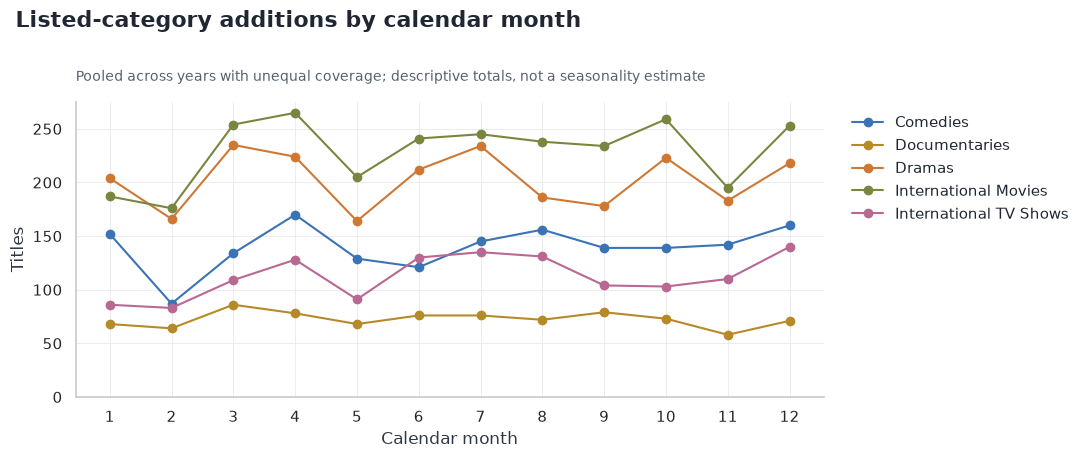

In [47]:
genre_month = pd.crosstab(genre_year_top5['added_month'], genre_year_top5['genre']).reindex(range(1, 13), fill_value=0)
ax = genre_month.plot(figsize=(11, 4.5), marker='o', color=PALETTE)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Calendar month')
ax.set_ylabel('Titles')
ax.set_ylim(bottom=0)
ax.legend(title=None, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
finish_plot(ax, 'Listed-category additions by calendar month',
            'Pooled across years with unequal coverage; descriptive totals, not a seasonality estimate')

**Interpretation:** International Movies and Dramas are the two largest listed
categories. This describes catalog supply. Evaluating further investment would
require viewing engagement, licensing costs, and retention evidence.

### 8. Ratings and content classification

Ratings are content classifications, not viewer review scores. The three misplaced runtimes were repaired before aggregation; unknown classifications remain visible.

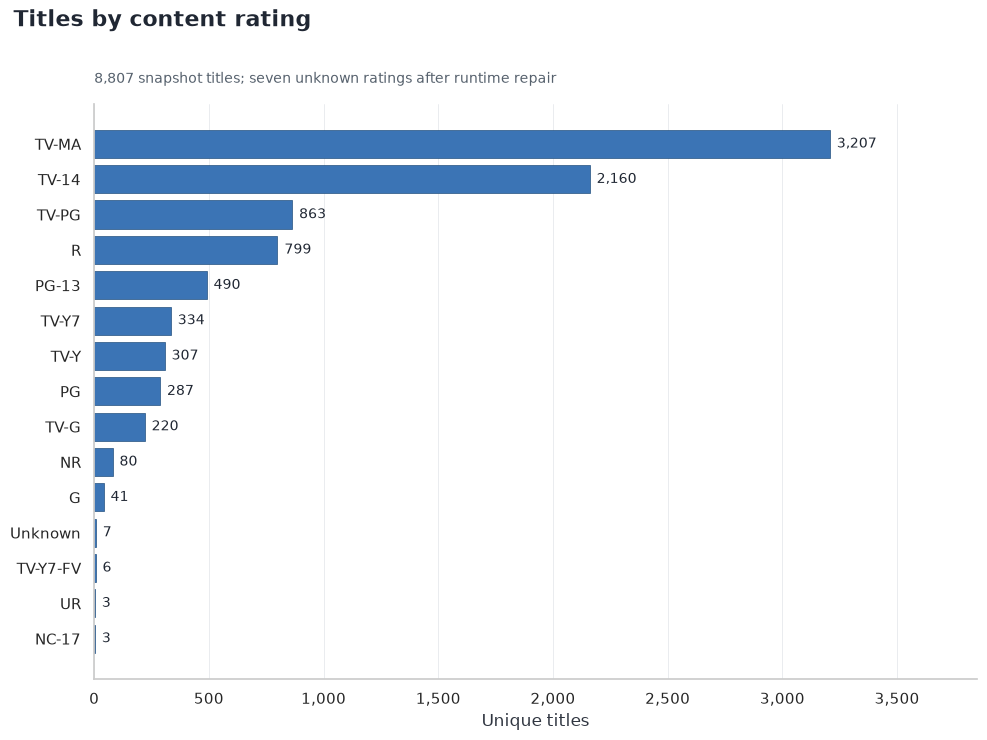

In [48]:
rating_count = df_clean['rating'].value_counts(dropna=False)
rank_plot(rating_count, 'Titles by content rating',
          '8,807 snapshot titles; seven unknown ratings after runtime repair', 'content_ratings.png')

#### How do ratings differ between Movies and TV Shows?

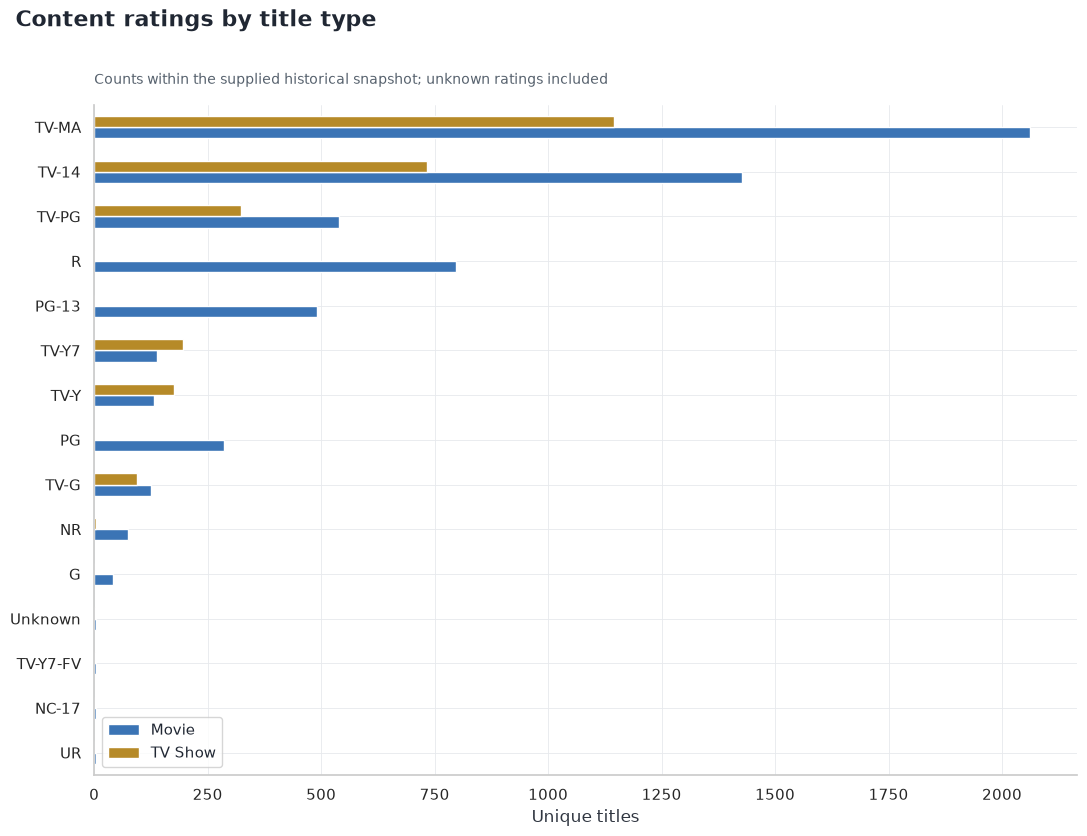

In [49]:
rating_type = pd.crosstab(df_clean['rating'], df_clean['type'])
grouped_plot(rating_type.loc[rating_count.index].iloc[::-1], 'Content ratings by title type',
             'Counts within the supplied historical snapshot; unknown ratings included')

#### Percentage of each content type in each rating

In [50]:
# Each content-type column sums to 100%; rows would answer a different question.
rating_type_percentage = pd.crosstab(df_clean['rating'], df_clean['type'], normalize='columns').mul(100)
assert np.allclose(rating_type_percentage.sum(), 100)
rating_type_percentage.round(2)

type,Movie,TV Show
rating,,
G,0.67,0.00
NC-17,0.05,0.00
NR,1.22,0.19
PG,4.68,0.00
PG-13,7.99,0.00
R,13.00,0.07
TV-14,23.28,27.39
TV-G,2.06,3.51
TV-MA,33.63,42.79


#### Which ratings are most common within Movies?

In [51]:
movie_rating = df_clean[df_clean['type']=='Movie']['rating'].value_counts(normalize=True)*100
movie_rating.head(5)



rating
TV-MA    33.632360
TV-14    23.275159
R        12.999511
TV-PG     8.807699
PG-13     7.992171
Name: proportion, dtype: float64

In [52]:
tv_show_rating = df_clean[df_clean['type']=='TV Show']['rating'].value_counts(normalize=True)*100
tv_show_rating.head(3)

rating
TV-MA    42.787743
TV-14    27.391629
TV-PG    12.070254
Name: proportion, dtype: float64

#### Are ratings changing over time?

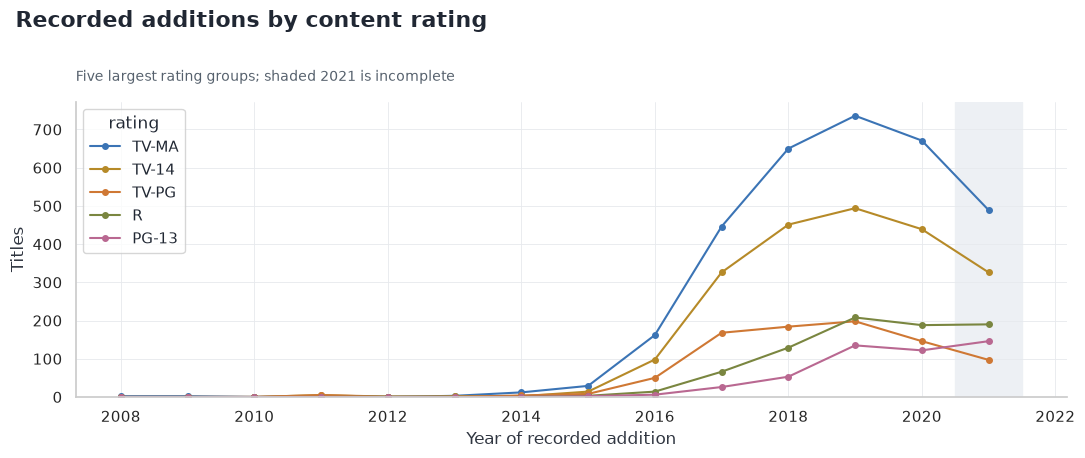

In [53]:
rating_year = pd.crosstab(df_clean['added_year'], df_clean['rating'])
top_ratings = rating_count.head(5).index
trend_plot(rating_year[top_ratings], 'Recorded additions by content rating',
           'Five largest rating groups; shaded 2021 is incomplete')

### 9. Directors and actors

Rankings exclude unknown names. Association with a title does not imply exclusivity or commercial success.

#### Which directors are associated with the largest number of Netflix titles?

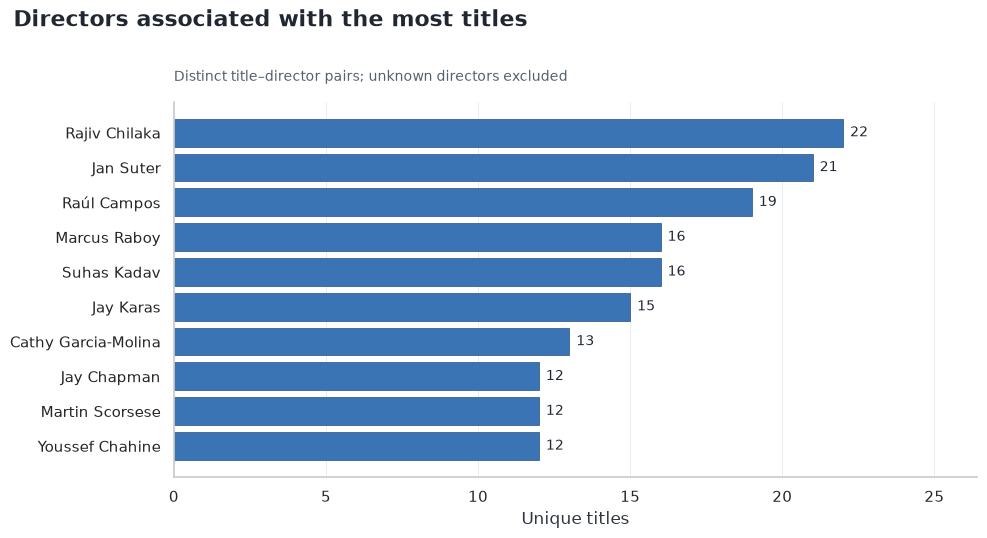

In [54]:
director_count = title_director['director'].value_counts().head(10)
rank_plot(director_count, 'Directors associated with the most titles', 'Distinct title–director pairs; unknown directors excluded')

#### Are the top directors primarily associated with Movies or TV Shows?

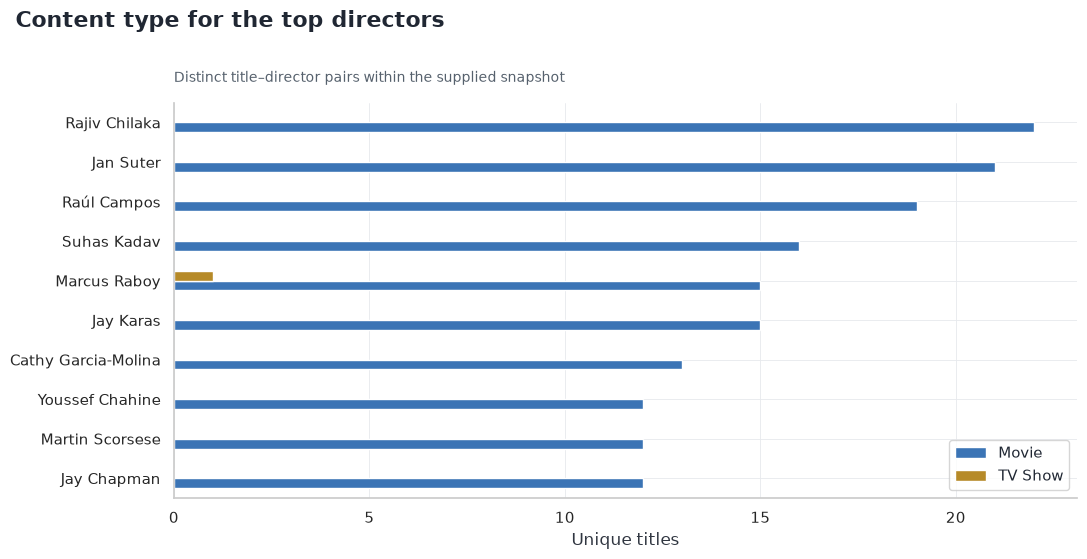

In [55]:
director_type = title_director.merge(df_clean[['show_id', 'type']], on='show_id', how='left', validate='many_to_one')
director_type_table = pd.crosstab(director_type['director'], director_type['type'])
grouped_plot(director_type_table.loc[director_count.index].iloc[::-1], 'Content type for the top directors',
             'Distinct title–director pairs within the supplied snapshot')

#### Which actors appear in the largest number of Netflix titles?

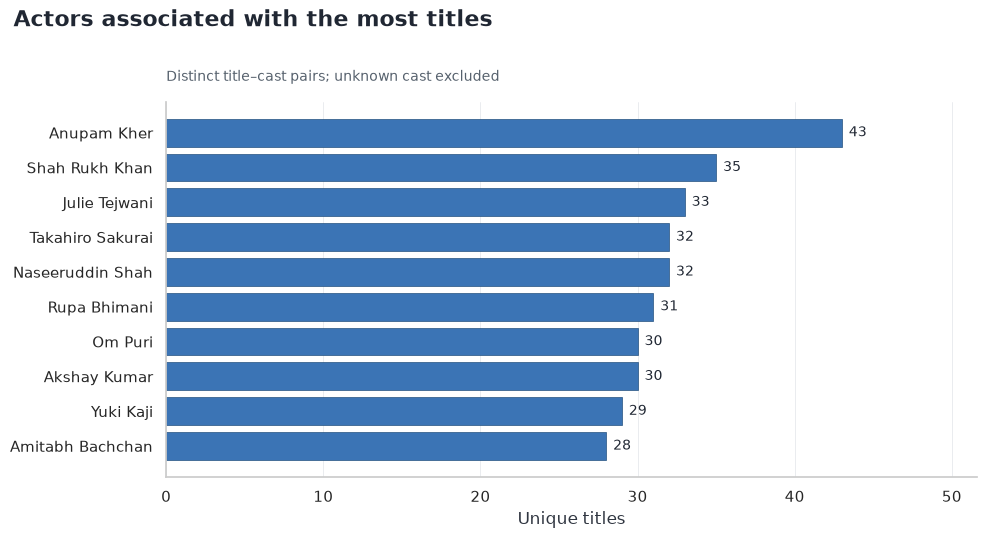

In [56]:
actor_count = title_cast['cast_member'].value_counts().head(10)
rank_plot(actor_count, 'Actors associated with the most titles', 'Distinct title–cast pairs; unknown cast excluded')

#### Are the top actors primarily associated with Movies or TV Shows?

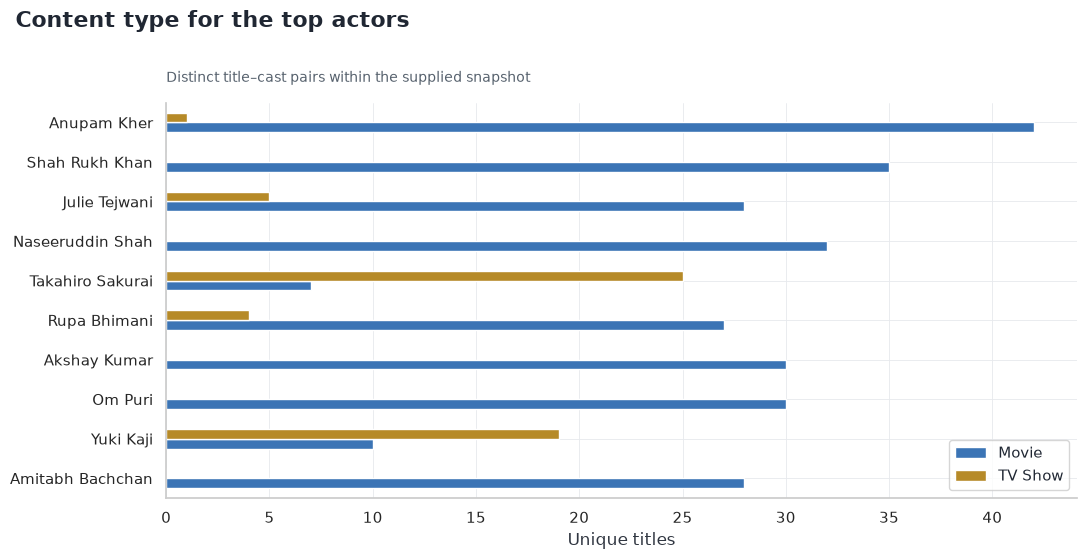

In [57]:
actor_type = title_cast.merge(df_clean[['show_id', 'type']], on='show_id', how='left', validate='many_to_one')
actor_type_table = pd.crosstab(actor_type['cast_member'], actor_type['type'])
top_actors = actor_count.index
grouped_plot(actor_type_table.loc[top_actors].iloc[::-1], 'Content type for the top actors',
             'Distinct title–cast pairs within the supplied snapshot')

#### Which actors have worked across both Movies and TV Shows?

In [58]:
actor_both = actor_type_table[(actor_type_table['Movie']>0) & (actor_type_table['TV Show']>0)]
actor_both.sort_values(by=['Movie','TV Show'],ascending=False).head(10)

type,Movie,TV Show
cast_member,,
Anupam Kher,42,1
Julie Tejwani,28,5
Rupa Bhimani,27,4
Samuel L. Jackson,22,2
Rajesh Kava,21,5
Kay Kay Menon,20,1
Nawazuddin Siddiqui,20,1
Nicolas Cage,20,1
John Cleese,19,5


#### Which countries are associated with the directors contributing the most titles?

In [59]:
# Intentional many-to-many join: one row per title–director–country combination.
director_country = title_director.merge(title_country[['show_id', 'country']], on='show_id', how='left')
director_country.head(5)

,show_id,title,director,country
0,s1,Dick Johnson Is Dead,Kirsten Johnson,United States
1,s3,Ganglands,Julien Leclercq,NaN
2,s6,Midnight Mass,Mike Flanagan,NaN
3,s7,My Little Pony: A New Generation,Robert Cullen,NaN
4,s7,My Little Pony: A New Generation,José Luis Ucha,NaN


In [60]:
director_country.groupby(['director', 'country'])['show_id'].nunique().sort_values(ascending=False).head(20)

director             country      
Jay Karas            United States    15
Marcus Raboy         United States    15
Cathy Garcia-Molina  Philippines      13
Martin Scorsese      United States    12
Jay Chapman          United States    12
Jan Suter            Mexico           12
Youssef Chahine      Egypt            12
Steven Spielberg     United States    11
Raúl Campos          Mexico           10
Don Michael Paul     United States    10
Yılmaz Erdoğan       Turkey            9
David Dhawan         India             9
Anurag Kashyap       India             9
Shannon Hartman      United States     9
Hakan Algül          Turkey            8
Hanung Bramantyo     Indonesia         8
Robert Rodriguez     United States     8
Ryan Polito          United States     8
Justin G. Dyck       Canada            8
Umesh Mehra          India             8
Name: show_id, dtype: int64

### 10. Movie runtime and TV-show seasons

Minutes and seasons are analyzed separately. Unusually short or long titles are retained unless source evidence establishes an error.

#### What is the typical Movie runtime?

In [61]:
df_clean['movie_duration_min'].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: movie_duration_min, dtype: float64

In [62]:
movie_mean = df_clean['movie_duration_min'].mean()
movie_median = df_clean['movie_duration_min'].median()
print(f'Mean movie runtime: {movie_mean:.1f} minutes; median: {movie_median:.0f} minutes.')

Mean movie runtime: 99.6 minutes; median: 98 minutes.


#### What does the Movie duration distribution look like?

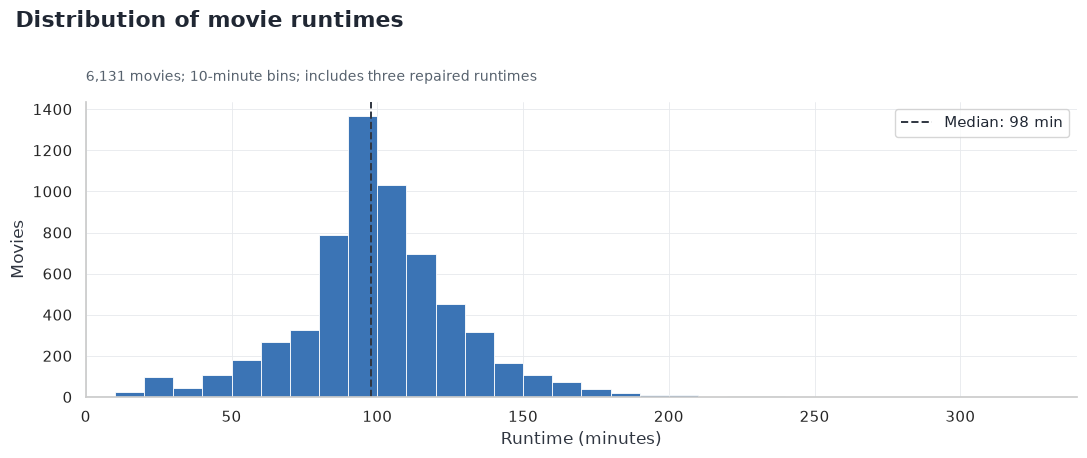

In [63]:
movie_runtime = df_clean['movie_duration_min'].dropna()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(movie_runtime, bins=np.arange(0, 341, 10), color=BLUE, edgecolor='white', linewidth=0.6)
ax.axvline(movie_median, color='#303641', linestyle='--', linewidth=1.4,
           label=f'Median: {movie_median:.0f} min')
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Movies')
ax.set_xlim(0, 340)
ax.legend()
finish_plot(ax, 'Distribution of movie runtimes',
            f'{len(movie_runtime):,} movies; 10-minute bins; includes three repaired runtimes',
            'movie_duration_distribution.png')

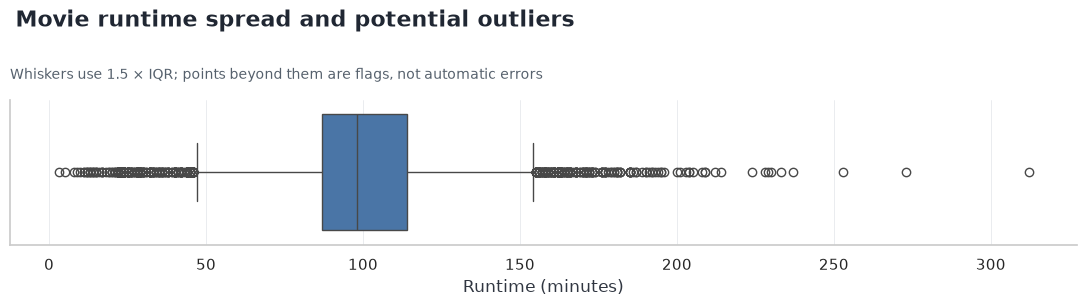

In [64]:
fig, ax = plt.subplots(figsize=(11, 3))
sns.boxplot(x=movie_runtime, color=BLUE, ax=ax)
ax.set_xlabel('Runtime (minutes)')
finish_plot(ax, 'Movie runtime spread and potential outliers',
            'Whiskers use 1.5 × IQR; points beyond them are flags, not automatic errors')

#### Inspect duration outliers

Review flagged records before deciding whether they are errors. The raw CSV
contains short films and unusually long titles; the IQR rule alone does not
justify deleting them.

In [65]:
q1, q3 = movie_runtime.quantile([0.25, 0.75])
iqr = q3 - q1
runtime_outliers = df_clean.loc[(df_clean['movie_duration_min'] < q1 - 1.5 * iqr) | (df_clean['movie_duration_min'] > q3 + 1.5 * iqr)]
print(f'{len(runtime_outliers)} movies flagged by the IQR rule; retained for analysis.')
runtime_outliers[['title', 'movie_duration_min']].sort_values('movie_duration_min').head(10)

450 movies flagged by the IQR rule; retained for analysis.


,title,movie_duration_min
3777,Silent,3.0
2713,Sol Levante,5.0
1484,Cops and Robbers,8.0
1557,Canvas,9.0
3535,American Factory: A Conversation with the Obamas,10.0
6405,Calico Critters: A Town of Dreams,11.0
2858,Calico Critters: Everyone's Big Dream Flying i...,11.0
4707,Zion,12.0
3775,Cosmos Laundromat: First Cycle,12.0
695,Besieged Bread,12.0


#### Which Movie duration range is most common?

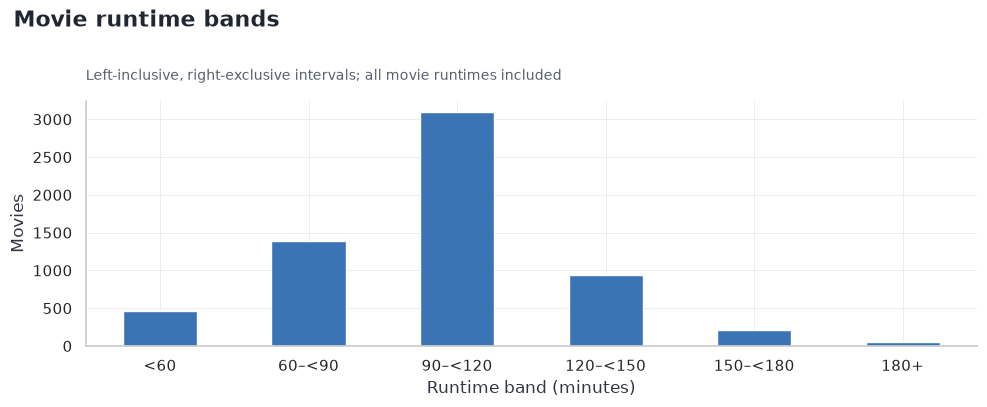

In [66]:
bins = [0, 60, 90, 120, 150, 180, np.inf]
labels = ['<60', '60–<90', '90–<120', '120–<150', '150–<180', '180+']
df_clean['movie_duration_group'] = pd.cut(df_clean['movie_duration_min'], bins=bins, labels=labels, right=False)
ax = df_clean['movie_duration_group'].value_counts(sort=False).plot.bar(figsize=(10, 4), color=BLUE, rot=0)
ax.set_xlabel('Runtime band (minutes)')
ax.set_ylabel('Movies')
finish_plot(ax, 'Movie runtime bands', 'Left-inclusive, right-exclusive intervals; all movie runtimes included')

#### How many seasons do Netflix TV Shows typically have?

In [67]:
nona_season = df_clean[df_clean['tv_seasons'].notna()]

In [68]:
nona_season['tv_seasons'].describe()

count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: tv_seasons, dtype: float64

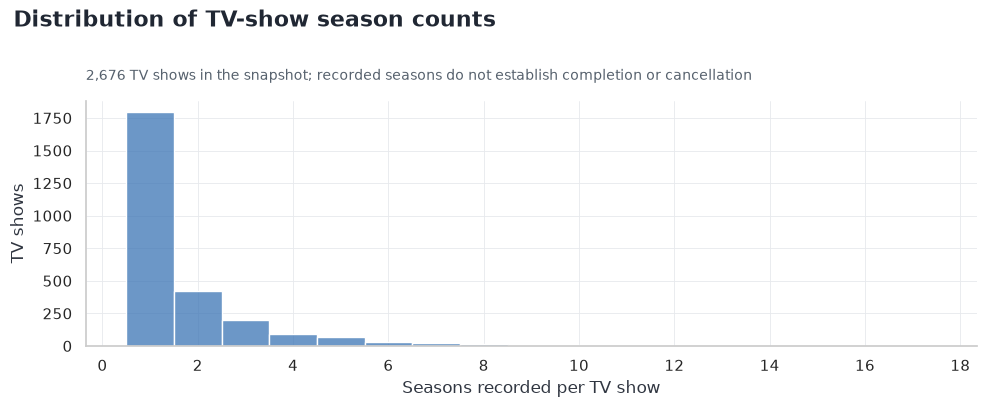

In [69]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=nona_season, x='tv_seasons', discrete=True, color=BLUE, ax=ax)
ax.set_xlabel('Seasons recorded per TV show')
ax.set_ylabel('TV shows')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
finish_plot(ax, 'Distribution of TV-show season counts',
            '2,676 TV shows in the snapshot; recorded seasons do not establish completion or cancellation')

#### How many TV Shows are single-season?

In [70]:
single_season = nona_season[nona_season['tv_seasons']==1.0]
single_season['tv_seasons'].shape[0]

1793

In [71]:
single_season_percentage = df_clean['tv_seasons'].eq(1).sum() / df_clean['tv_seasons'].notna().sum() * 100
print(f'{len(single_season):,} of {len(nona_season):,} TV shows have one recorded season ({single_season_percentage:.1f}%).')

1,793 of 2,676 TV shows have one recorded season (67.0%).


#### duration by release year

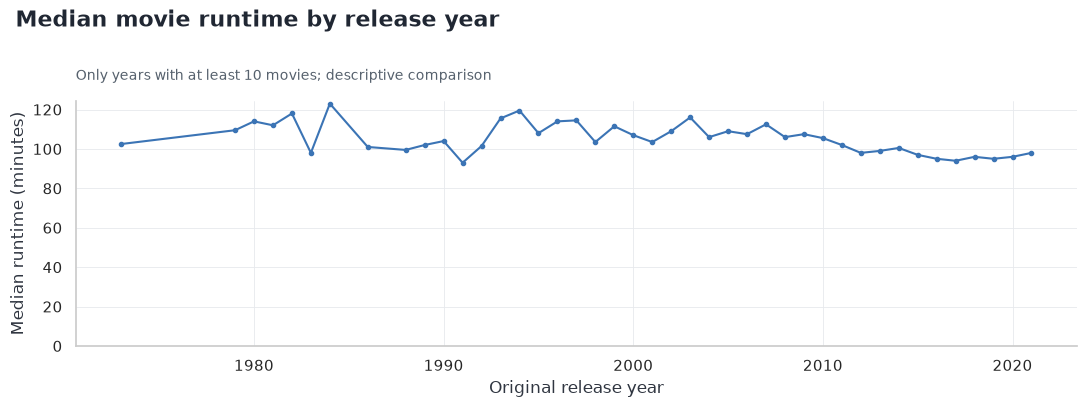

In [72]:
runtime_by_release = df_clean.loc[df_clean['type'].eq('Movie')].groupby('release_year')['movie_duration_min'].agg(['median', 'count'])
# Bound sparse early years rather than presenting their medians as equally reliable.
enough_movies = runtime_by_release.loc[runtime_by_release['count'] >= 10]
ax = enough_movies['median'].plot(figsize=(11, 4), marker='o', markersize=3, color=BLUE)
ax.set_xlabel('Original release year')
ax.set_ylabel('Median runtime (minutes)')
ax.set_ylim(bottom=0)
finish_plot(ax, 'Median movie runtime by release year', 'Only years with at least 10 movies; descriptive comparison')

### 11. Release years and age at recorded addition

#### What is the distribution of content by release year?

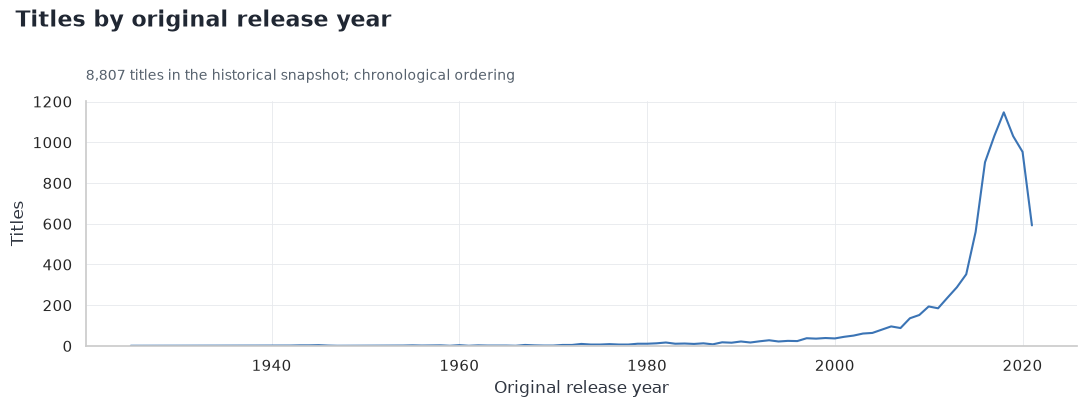

In [73]:
release_year_count = df_clean['release_year'].value_counts().sort_index()
ax = release_year_count.plot(figsize=(11, 4), color=BLUE)
ax.set_xlabel('Original release year')
ax.set_ylabel('Titles')
ax.set_ylim(bottom=0)
finish_plot(ax, 'Titles by original release year', '8,807 titles in the historical snapshot; chronological ordering')

In [74]:
peak_year = added_year_count.idxmax()
peak_count = added_year_count.max()
print(f'The largest recorded annual count is {peak_count:,} titles in {peak_year}; 2021 is partial.')

The largest recorded annual count is 2,016 titles in 2019; 2021 is partial.


In [75]:
df_clean['content_age_when_added'] = df_clean['added_year'] - df_clean['release_year']
negative_age = df_clean['content_age_when_added'].lt(0).fillna(False)
df_clean['valid_content_age_years'] = df_clean['content_age_when_added'].mask(negative_age)
print(f'{negative_age.sum()} negative year differences excluded from age summaries; source rows retained.')
df_clean['valid_content_age_years'].describe()

14 negative year differences excluded from age summaries; source rows retained.


count      8783.0
mean     4.697825
std      8.790808
min           0.0
25%           0.0
50%           1.0
75%           5.0
max          93.0
Name: valid_content_age_years, dtype: Float64

#### Share of recorded annual additions by content type

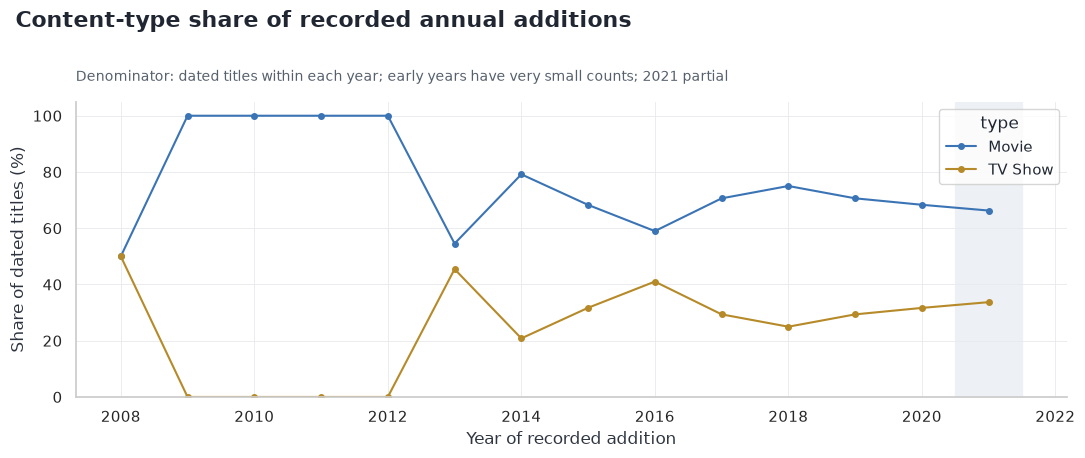

In [76]:
content_growth_pct = pd.crosstab(df_clean['added_year'], df_clean['type'], normalize='index').mul(100)
trend_plot(content_growth_pct, 'Content-type share of recorded annual additions',
           'Denominator: dated titles within each year; early years have very small counts; 2021 partial',
           ylabel='Share of dated titles (%)')

#### Titles released within five calendar years of their recorded addition

In [77]:
valid_age = df_clean['valid_content_age_years'].dropna()
within_five_years = valid_age.between(0, 5).sum()
print(f'{within_five_years:,} / {len(valid_age):,} valid records ({within_five_years / len(valid_age):.1%}) fall within 0–5 years.')

6,659 / 8,783 valid records (75.8%) fall within 0–5 years.


#### Is Netflix adding newer or older content?

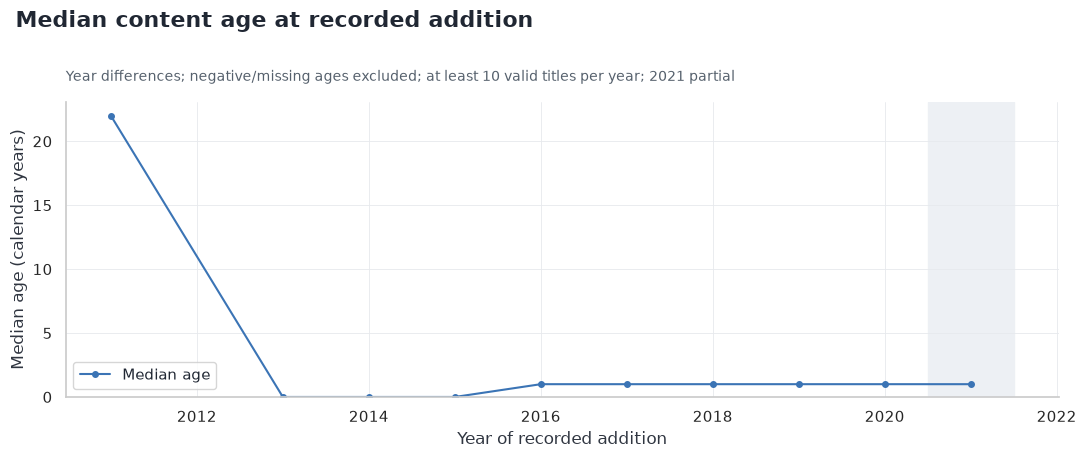

In [78]:
age_by_year = df_clean.groupby('added_year')['valid_content_age_years'].agg(['median', 'count'])
enough_titles = age_by_year.loc[age_by_year['count'] >= 10]
trend_plot(enough_titles[['median']].rename(columns={'median': 'Median age'}),
           'Median content age at recorded addition',
           'Year differences; negative/missing ages excluded; at least 10 valid titles per year; 2021 partial',
           ylabel='Median age (calendar years)')

In [79]:
df_clean.loc[negative_age, ['title', 'release_year', 'added_year', 'content_age_when_added']].head(14)

,title,release_year,added_year,content_age_when_added
1551,Hilda,2021,2020,-1
1696,Polly Pocket,2021,2020,-1
2920,Love Is Blind,2021,2020,-1
3168,Fuller House,2020,2019,-1
3287,Maradona in Mexico,2020,2019,-1
3369,BoJack Horseman,2020,2019,-1
3433,The Hook Up Plan,2020,2019,-1
4844,Unbreakable Kimmy Schmidt,2019,2018,-1
4845,Arrested Development,2019,2018,-1
5394,Hans Teeuwen: Real Rancour,2018,2017,-1


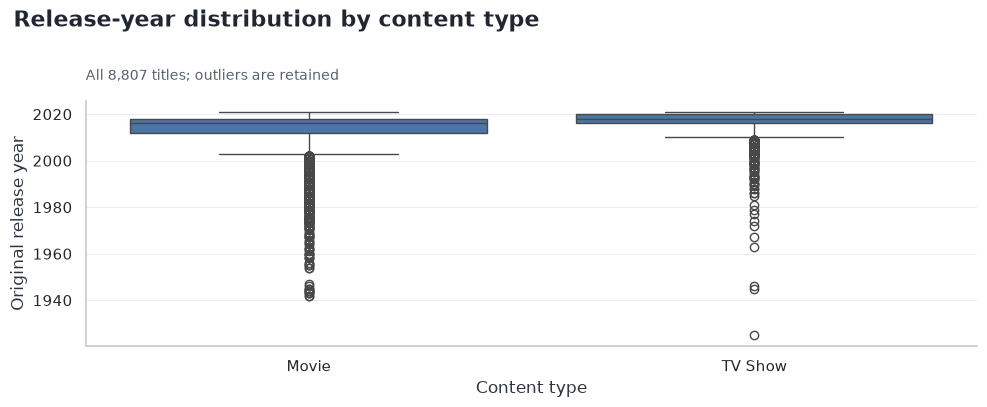

In [80]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df_clean, x='type', y='release_year', color=BLUE, ax=ax)
ax.set_xlabel('Content type')
ax.set_ylabel('Original release year')
finish_plot(ax, 'Release-year distribution by content type', 'All 8,807 titles; outliers are retained')

### 12. Country × listed-category relationships

#### Compare the five largest countries and listed categories

The country–genre join intentionally creates multiple combinations per title. Each heatmap cell counts unique titles for that particular pair; cells are not additive.

In [81]:
top5_countries = (
    title_country['country']
    .value_counts()
    .head(5)
    .index
)

top5_genres = (
    title_genre['genre']
    .value_counts()
    .head(5)
    .index
)

In [82]:
country_genre = title_country.merge(title_genre[['show_id', 'genre']], on='show_id', how='inner')
cg = country_genre.loc[country_genre['country'].isin(top5_countries) & country_genre['genre'].isin(top5_genres)]
country_genre_table = cg.groupby(['country', 'genre'])['show_id'].nunique().unstack(fill_value=0)
country_genre_table = country_genre_table.reindex(index=top5_countries, columns=top5_genres, fill_value=0)

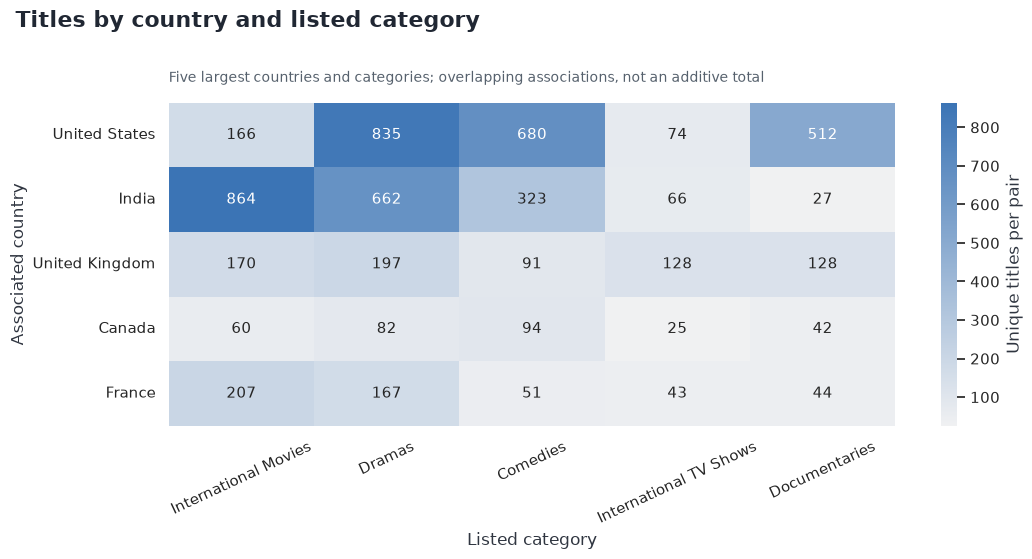

In [83]:
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(country_genre_table, annot=True, fmt='d', cmap=sns.light_palette(BLUE, as_cmap=True),
            cbar_kws={'label': 'Unique titles per pair'}, ax=ax)
ax.set_xlabel('Listed category')
ax.set_ylabel('Associated country')
ax.tick_params(axis='x', rotation=25)
finish_plot(ax, 'Titles by country and listed category',
            'Five largest countries and categories; overlapping associations, not an additive total')

### 13. Concentration and addition-period mix

#### Share of metadata relationships in the five largest categories

These percentages use relationship counts as their denominator. They are distinct from the percentage of unique titles associated with those categories.

In [84]:
country_count = title_country['country'].value_counts()
top5_country_share = country_count.head(5).sum() / len(title_country) * 100
top5_country_title_coverage = title_country.loc[title_country['country'].isin(country_count.head(5).index), 'show_id'].nunique() / len(df_clean) * 100
print(f'Top five countries: {top5_country_share:.1f}% of named country relationships.')
print(f'Titles with at least one top-five country: {top5_country_title_coverage:.1f}% of all titles.')

Top five countries: 63.7% of named country relationships.
Titles with at least one top-five country: 64.2% of all titles.


In [85]:
genre_counts = title_genre['genre'].value_counts()
top5_genre_share = genre_counts.head(5).sum() / len(title_genre) * 100
print(f'Top five listed categories: {top5_genre_share:.1f}% of title–category relationships.')

Top five listed categories: 47.0% of title–category relationships.


In [86]:
recent = df_clean.loc[df_clean['added_year'].ge(2020)]
comparison = pd.DataFrame({
    'All snapshot titles (%)': df_clean['type'].value_counts(normalize=True).mul(100),
    'Additions recorded 2020–Sep 2021 (%)': recent['type'].value_counts(normalize=True).mul(100),
})
print(f'Addition-period denominator: {len(recent):,} dated titles; 2021 is incomplete.')
comparison.round(1)

Addition-period denominator: 3,377 dated titles; 2021 is incomplete.


,All snapshot titles (%),Additions recorded 2020–Sep 2021 (%)
type,,
Movie,69.6,67.4
TV Show,30.4,32.6


### 14. Final quality checks

Validate title grain, relationships, unit separation, and the headline values. The raw file is never overwritten.

In [87]:
relations = [(title_director, 'director'), (title_cast, 'cast_member'),
             (title_country, 'country'), (title_genre, 'genre')]
audit_rows = []
for table, attribute in relations:
    assert not table.duplicated(['show_id', attribute]).any()
    assert table['show_id'].isin(df_clean['show_id']).all()
    assert not table[attribute].isin(['Unknown', '']).any()
    audit_rows.append({'Relationship': attribute, 'Pairs': len(table),
                       'Titles covered': table['show_id'].nunique()})
pd.DataFrame(audit_rows)

,Relationship,Pairs,Titles covered
0,director,6977,6173
1,cast_member,64124,7982
2,country,10012,7976
3,genre,19323,8807


In [88]:
assert len(df_clean) == len(df) == 8807
assert df_clean['show_id'].is_unique
assert type_counts.sum() == len(df_clean)
assert df_clean.loc[df_clean['type'].eq('Movie'), 'tv_seasons'].isna().all()
assert df_clean.loc[df_clean['type'].eq('TV Show'), 'movie_duration_min'].isna().all()
assert not df_clean['rating'].str.contains('min', na=False).any()
assert df_clean['movie_duration_min'].notna().sum() == type_counts['Movie']
assert added_year_count.sum() == df_clean['date_added'].notna().sum()
print('Title grain, relationship integrity, date totals, and runtime units validated.')

Title grain, relationship integrity, date totals, and runtime units validated.


## Takeaways

- **Movies dominate this snapshot:** 6,131 of 8,807 titles (69.6%).
- **2019 has the largest recorded annual addition count:** 2,016 titles.
  A lower 2021 count is not evidence of a slowdown because 2021 is incomplete.
- **The United States has the most associated titles:** 3,690 distinct titles,
  followed by India (1,046). Co-production counts overlap.
- **International Movies is the largest listed category:** 2,752 titles;
  Dramas follows with 2,427. These are catalog labels, not measures of demand.
- **TV-MA is the largest content-rating category:** 3,207 titles.
- **The median movie runtime is 98 minutes.** Of 2,676 TV shows, 1,793 (67.0%)
  have one recorded season; this does not imply cancellation or completion.

### Business implications and next questions

Use this work as a catalog inventory baseline. To evaluate a content gap or
investment opportunity, combine the observed mix with market-specific
availability, audience engagement, retention, and licensing-cost data. Compare
complete observation periods and account for removals before assessing growth.

### Limitations

The source is a historical metadata snapshot with missing country, director,
and cast fields. Missingness may bias contributor and geographic rankings.
Multi-label relationships overlap; year-based age is approximate and 14
negative differences are excluded from age summaries. The upstream publisher
and license are not documented in the original repository.